# F7 — Week 10 Performance Review

**Objective**: Review the optimisation performance of F7 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F7 (6D input, 1D output, maximisation)

This notebook loads the Week 10 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 7
N_DIMS = 6
N_INITIAL = 30
WEEK = 10
USE_LOG_SCALE = False
DATA_DIR = '../../data/f7/'

## Step 1 — Load Data

In [2]:
# Load Week 10 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F7 — Week 10 Data Summary
  Input dimensions:  6
  Total samples:     40
  Initial samples:   30
  Submissions:       10
  Input shape:       (40, 6)
  Output shape:      (40,)
  Best output:       2.30499
  Worst output:      0.00270147

Sample | x1 | x2 | x3 | x4 | x5 | x6 | y
-------------------------------------------------------------------------------------------------
   1(init) | 0.272624 | 0.324495 | 0.897109 | 0.832951 | 0.154063 | 0.795864 | 0.604433
   2(init) | 0.543003 | 0.924694 | 0.341567 | 0.646486 | 0.718440 | 0.343133 | 0.562753
   3(init) | 0.090832 | 0.661529 | 0.065931 | 0.258577 | 0.963453 | 0.640265 | 0.00750324
   4(init) | 0.118867 | 0.615055 | 0.905816 | 0.855300 | 0.413631 | 0.585236 | 0.0614243
   5(init) | 0.630218 | 0.838097 | 0.680013 | 0.731895 | 0.526737 | 0.348429 | 0.273047
   6(init) | 0.764919 | 0.255883 | 0.609084 | 0.218079 | 0.322943 | 0.095794 | 0.0837466
   7(init) | 0.057896 | 0.491672 | 0.247422 | 0.218118 | 0.420428 | 0.730970 | 1.36497
   

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

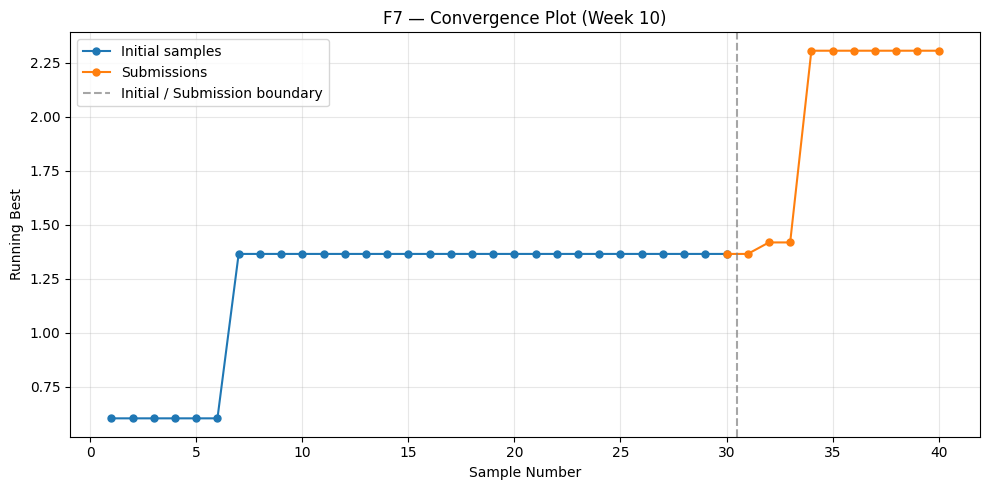

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

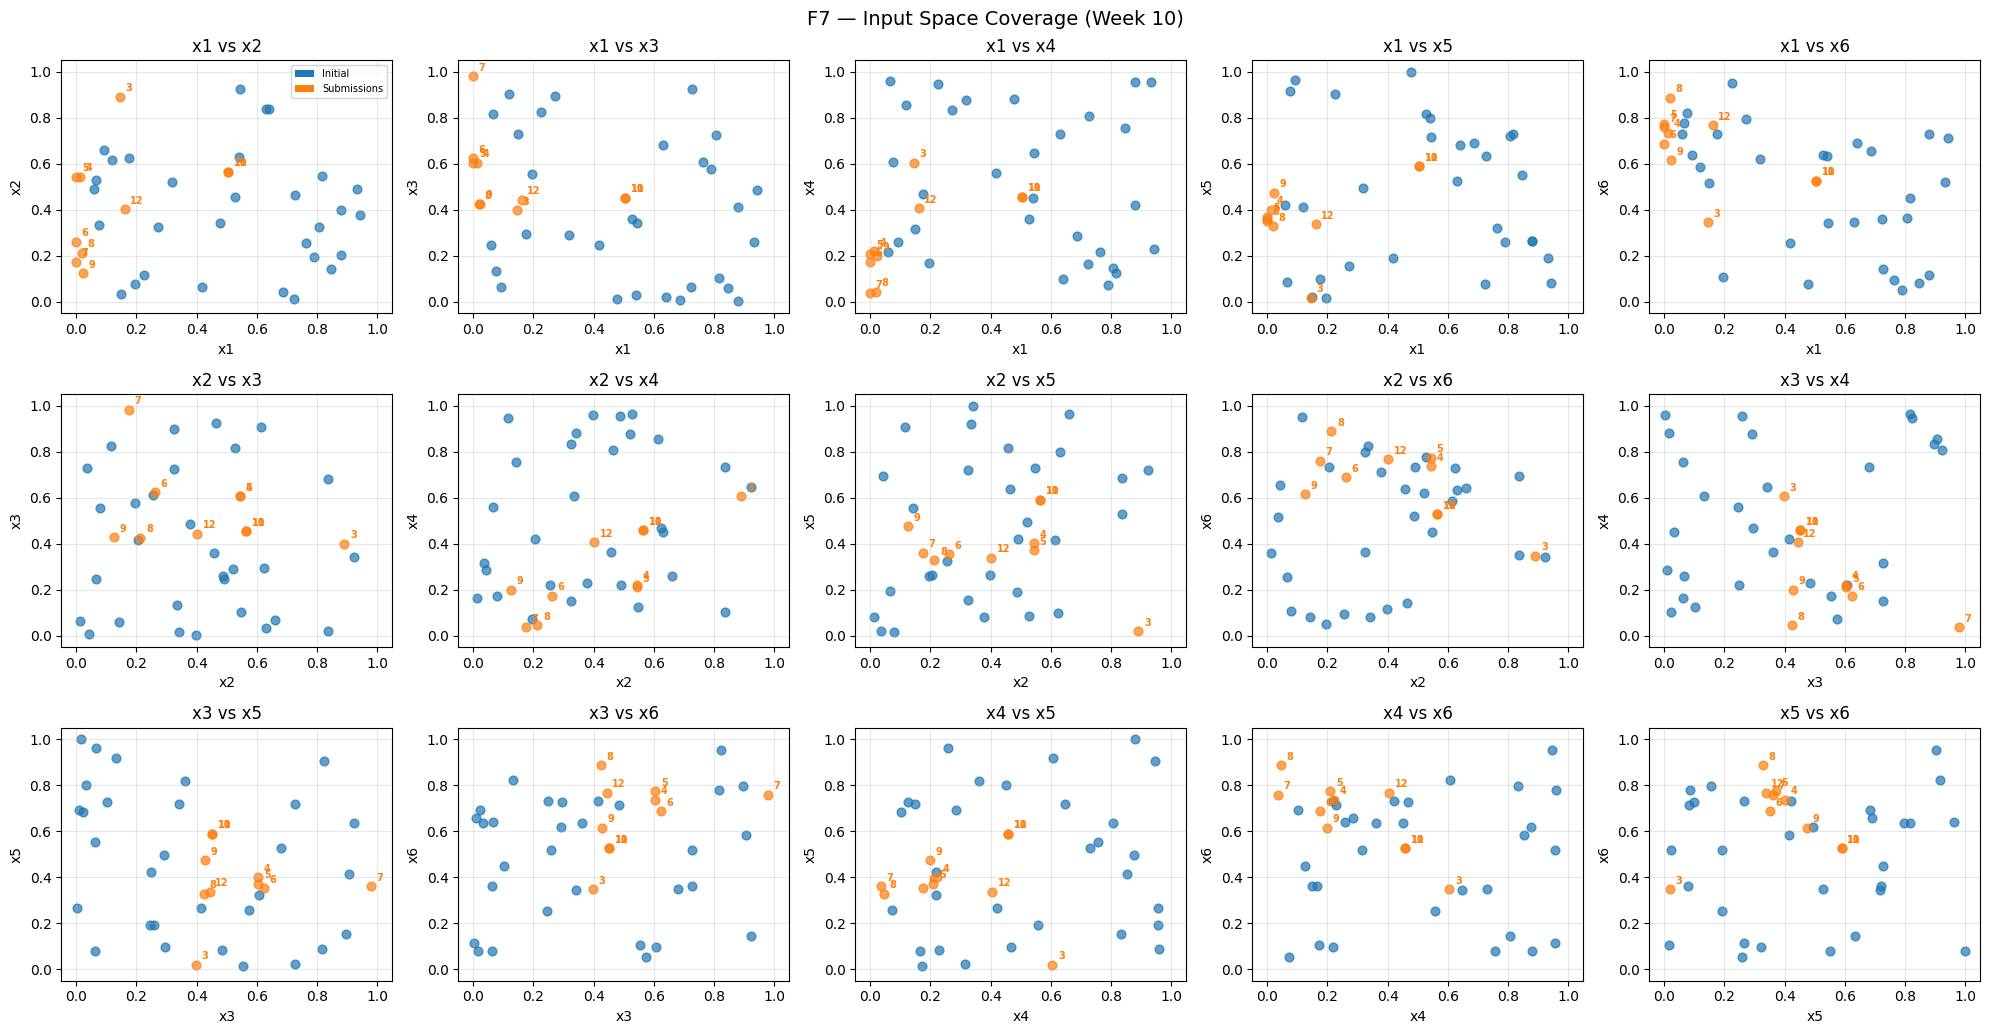

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: Neural Network (6→5→5→1, dropout=0.05)
- **Acquisition**: 70% mean + 30% EI blend, interior penalty
- **Key hyperparameters**: lr=0.005, 200 epochs, 20k candidates, STEEPNESS=0.05

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     1.36497
Best value (final):       2.30499
Improvements:             2/10
Max consecutive no-improve: 6
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       0.285444 |        1.36497 | ✗
   4 |        1.41816 |        1.41816 | ✓
   5 |        1.40491 |        1.41816 | ✗
   6 |        2.30499 |        2.30499 | ✓
   7 |       0.747724 |        2.30499 | ✗
   8 |        1.17215 |        2.30499 | ✗
   9 |        1.91349 |        2.30499 | ✗
  10 |       0.300001 |        2.30499 | ✗
  11 |       0.300001 |        2.30499 | ✗
  12 |        2.04327 |        2.30499 | ✗


### Evaluation

F7 has shown **limited progress** with **2 improvements** in 10 submission rounds. The best value moved from 1.365 (initial) to 2.305, but 6 consecutive non-improving submissions indicate the approach has plateaued.

Key observations:
- Only 2/10 submissions improved the running best — both early, followed by a long plateau
- 6 consecutive non-improving submissions is the second-worst stalling after F1 and F2
- The NN surrogate (6→5→5→1) is a non-standard choice that lacks the uncertainty quantification of GP-based models
- The 70% mean + 30% EI blend heavily favours exploitation, which compounds the lack of proper uncertainty
- Interior penalty is constraining the search space but the penalty parameters may be suboptimal
- 6D input space with 15 pair plots — high-dimensional exploration is challenging with only 10 additional samples

**Stalling status**: YES — 6 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

F7 shows significant stalling (2/10 improvements, 6 consecutive non-improving). Major changes recommended:

1. **Consider switching from NN to GP-based surrogate** — The NN (6→5→5→1) lacks principled uncertainty quantification. The 30% EI component relies on a variance proxy that may not calibrate well. An SFGP with Matérn-2.5 ARD would provide proper posterior uncertainty for the acquisition function.

2. **If keeping NN: increase EI weight from 30% to 50%** — The current 70% mean + 30% EI blend is too exploitative. The mean component drives the search to the predicted best, which after 6 consecutive failures is clearly a local optimum.

3. **Review interior penalty parameters** — The STEEPNESS=0.05 may be too aggressive, excluding potentially interesting boundary regions. Consider reducing to 0.02 or using a softer penalty function.

4. **Increase candidate pool from 20k to 50k** — In 6D, 20k random candidates provide sparse coverage. More candidates increase the chance of finding promising unexplored regions.

5. **Add ensemble or dropout-based uncertainty** — If keeping the NN, use MC dropout (multiple forward passes with dropout=0.05 enabled) to generate uncertainty estimates rather than relying on the deterministic variance proxy.

**Priority**: HIGH — The NN surrogate approach has fundamentally stalled and needs either significant reconfiguration or replacement.